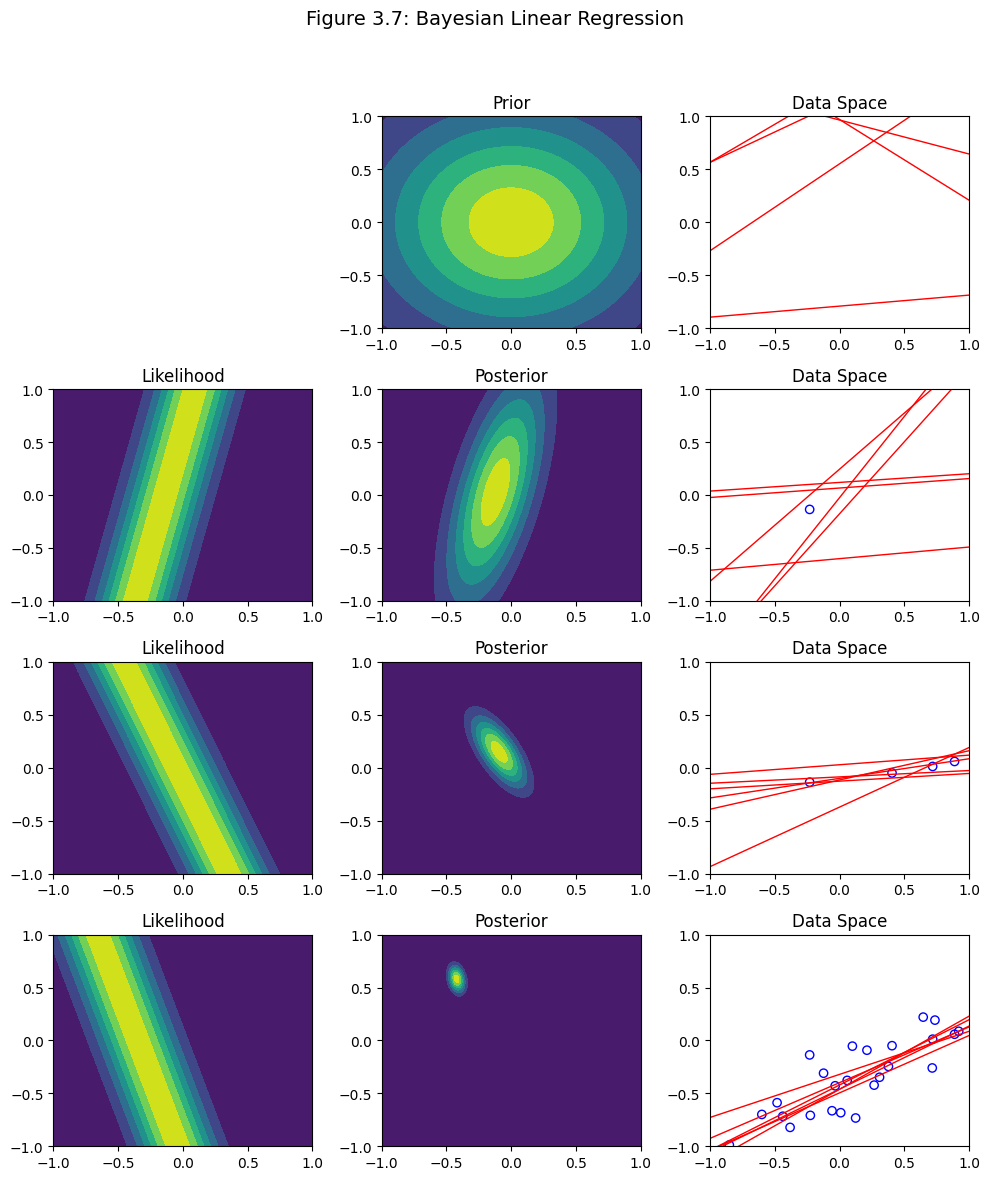

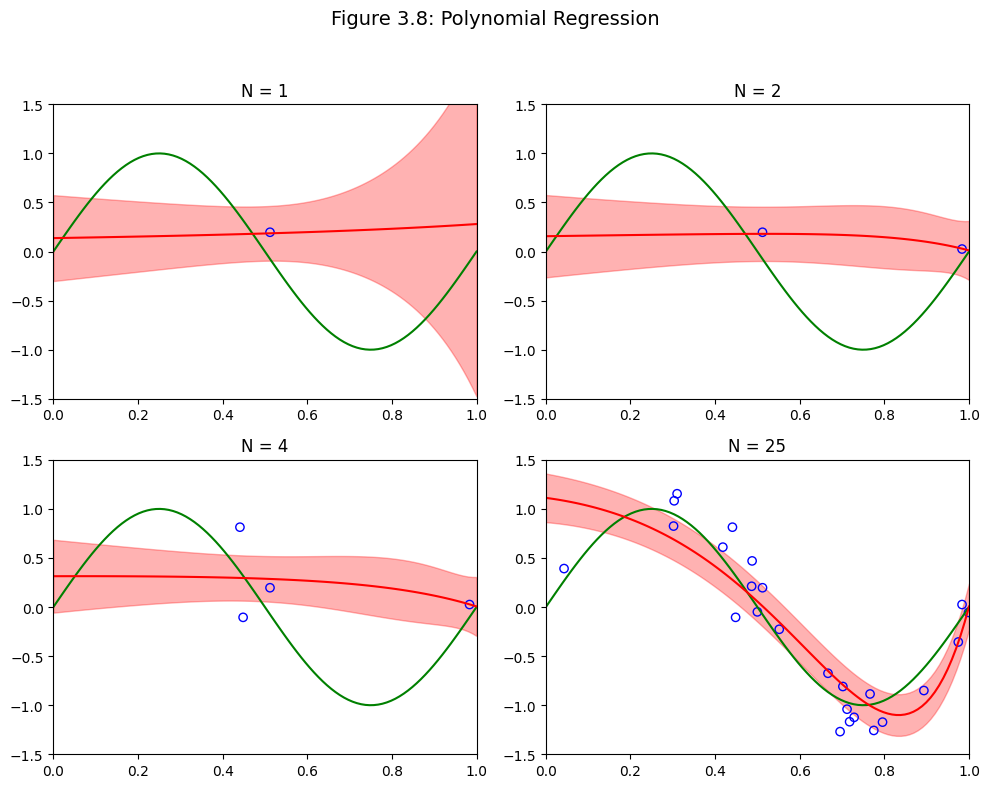

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA
# @ is matrix multiplication

# Set seed so results are repeatable
np.random.seed(38)


# Fig. 3.7 of tb
alpha = 2.0   # prior precision
beta = 25.0   # noise precision

# True line: y = -0.3 + 0.5x
true_weights = np.array([-0.3, 0.5])

# Generate x values for plotting
x_plot = np.linspace(-1, 1, 100)
ones_column = np.ones_like(x_plot) # _like, for this scenario, means array has the same data type and shape
design_x = np.column_stack((ones_column, x_plot))

# Training data
X = 2 * np.random.rand(25) - 1  # random x values in [-1, 1]
T = true_weights[0] + true_weights[1] * X + np.random.normal(0, np.sqrt(1 / beta), 25)

# Set up plots
fig, axs = plt.subplots(4, 3, figsize=(10, 12))
fig.suptitle("Figure 3.7: Bayesian Linear Regression", fontsize=14)

# Loop through different training sizes
for i, N in enumerate([0, 1, 4, 25]):
    if N > 0:
        x_train = X[:N]
        t_train = T[:N]
        Phi = np.column_stack((np.ones(N), x_train))  # Design matrix
    else:
        Phi = np.zeros((0, 2))
        t_train = np.zeros(0)

    # S_N equation from textbook
    S_N = LA.inv(alpha * np.eye(2) + beta * Phi.T @ Phi)

    if N > 0:
        posterior_mean = beta * S_N @ Phi.T @ t_train
    else:
        posterior_mean = np.zeros(2)

    # Create a grid of weights for contour plots
    w0_vals = np.linspace(-1, 1, 100)
    w1_vals = np.linspace(-1, 1, 100)
    W0, W1 = np.meshgrid(w0_vals, w1_vals)
    Z = np.zeros_like(W0)

    # Plot likelihood (for the last point only)
    if N > 0:
        for j in range(W0.shape[0]):
            for k in range(W0.shape[1]):
                w = np.array([W0[j, k], W1[j, k]])
                y_pred = w[0] + w[1] * x_train[-1]
                Z[j, k] = np.exp(-0.5 * beta * (y_pred - t_train[-1])**2)
        axs[i, 0].contourf(W0, W1, Z)
        axs[i, 0].set_title("Likelihood")
    else:
        axs[i, 0].axis("off")

    # Plot prior or posterior
    for j in range(W0.shape[0]):
        for k in range(W0.shape[1]):
            w = np.array([W0[j, k], W1[j, k]])
            diff = w - posterior_mean
            Z[j, k] = np.exp(-0.5 * diff @ LA.inv(S_N) @ diff)
    axs[i, 1].contourf(W0, W1, Z)
    axs[i, 1].set_title("Posterior" if N > 0 else "Prior")

    # Plot data space: sample 6 lines
    for b in range(6):
        sample_w = np.random.multivariate_normal(posterior_mean, S_N)
        y_plot = design_x @ sample_w
        axs[i, 2].plot(x_plot, y_plot, 'r', linewidth=1)

    if N > 0:
        axs[i, 2].scatter(x_train, t_train, facecolors='none', edgecolors='b')

    axs[i, 2].set_xlim(-1, 1)
    axs[i, 2].set_ylim(-1, 1)
    axs[i, 2].set_title("Data Space")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Fig. 3.8

def make_design_matrix(x, degree):
    # Creates a matrix s.t. each row is [1, x, x^2, ..., x^(degree-1)]
    return np.column_stack([x**i for i in range(degree)])

M = 9  # Polynomial degree
x_grid = np.linspace(0, 1, 100)
true_func = np.sin(2 * np.pi * x_grid)

# Generate training data from noisy sine wave
X = np.random.rand(25)
T = np.sin(2 * np.pi * X) + np.random.normal(0, np.sqrt(1 / beta), 25)

# Plot predictions with increasing N
fig2, axs2 = plt.subplots(2, 2, figsize=(10, 8))
fig2.suptitle("Figure 3.8: Polynomial Regression", fontsize=14)

for i, N in enumerate([1, 2, 4, 25]):
    x_train = X[:N]
    t_train = T[:N]

    Phi = make_design_matrix(x_train, M)
    S = LA.inv(alpha * np.eye(M) + beta * Phi.T @ Phi)
    m = beta * S @ Phi.T @ t_train

    Phi_test = make_design_matrix(x_grid, M)
    mean = Phi_test @ m
    var = 1 / beta + np.sum(Phi_test @ S * Phi_test, axis=1)
    std = np.sqrt(var)

    ax = axs2[i // 2, i % 2]
    ax.plot(x_grid, true_func, 'g', label='True Function')
    ax.plot(x_grid, mean, 'r', label='Predictive Mean')
    ax.fill_between(x_grid, mean - std, mean + std, color='red', alpha=0.3)
    ax.scatter(x_train, t_train, facecolors='none', edgecolors='b')
    ax.set_title(f"N = {N}")
    ax.set_xlim(0, 1)
    ax.set_ylim(-1.5, 1.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
